Archivos TIF encontrados: 24

Leyendo estadisticas de cada archivo TIF...
  eccCNRMCM5_15_39_rcp45_temp_prom.tif: 21.3C
  eccCNRMCM5_15_39_rcp85_temp_prom.tif: 21.36C
  eccCNRMCM5_45_69_rcp45_temp_prom.tif: 22.1C
  eccCNRMCM5_45_69_rcp85_temp_prom.tif: 22.66C
  eccCNRMCM5_75_99_rcp45_temp_prom.tif: 22.53C
  eccCNRMCM5_75_99_rcp85_temp_prom.tif: 24.19C
  eccGDFLCM3_15_39_rcp45_temp_prom.tif: 22.27C
  eccGDFLCM3_15_39_rcp85_temp_prom.tif: 22.15C
  eccGDFLCM3_45_69_rcp45_temp_prom.tif: 23.25C
  eccGDFLCM3_45_69_rcp85_temp_prom.tif: 24.06C
  eccGDFLCM3_75_99_rcp45_temp_prom.tif: 23.85C
  eccGDFLCM3_75_99_rcp85_temp_prom.tif: 26.05C
  eccHADGEM2ES_15_39_rcp45_temp_prom.tif: 21.91C
  eccHADGEM2ES_15_39_rcp85_temp_prom.tif: 22.05C
  eccHADGEM2ES_45_69_rcp45_temp_prom.tif: 22.99C
  eccHADGEM2ES_45_69_rcp85_temp_prom.tif: 23.84C
  eccHADGEM2ES_75_99_rcp45_temp_prom.tif: 23.55C
  eccHADGEM2ES_75_99_rcp85_temp_prom.tif: 26.03C
  eccMPIESMLR_15_39_rcp45_temp_prom.tif: 21.67C
  eccMPIESMLR_15_39_rc

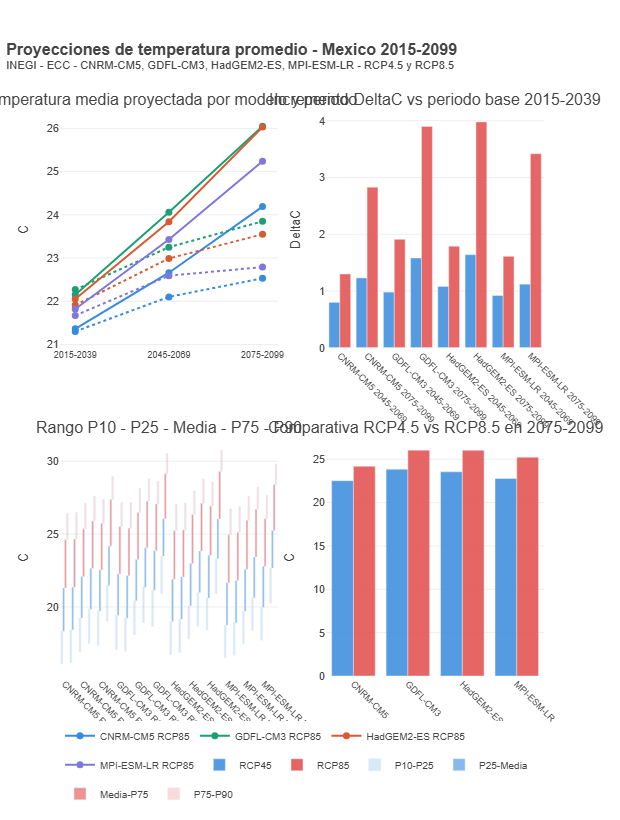

OK - Dashboard guardado: dashboard_temperatura_ecc.html


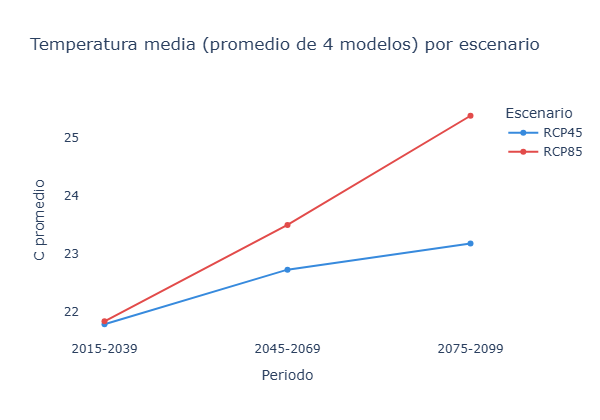

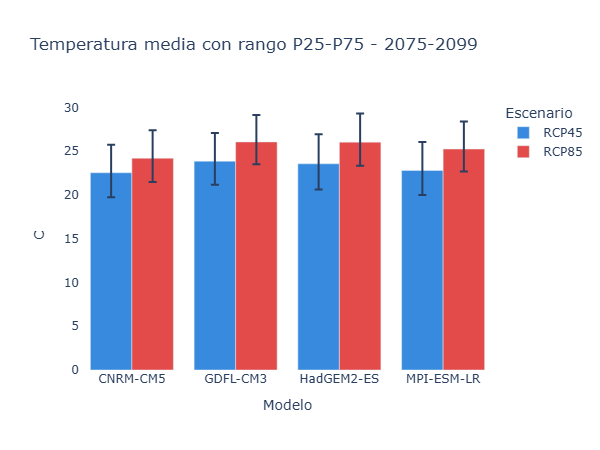

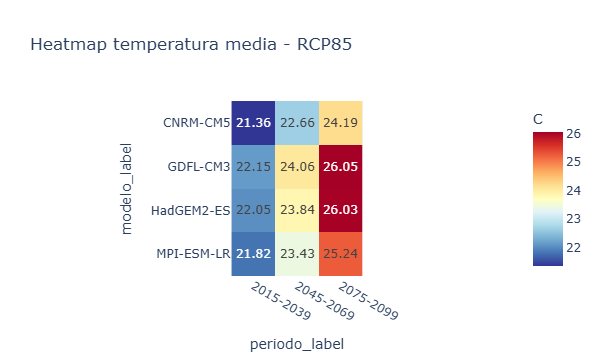


OK - Todas las graficas generadas correctamente.


In [6]:
#Dashboard de Proyecciones de Temperatura Promedio — México
#INEGI · Escenarios de Cambio Climático (ECC)
#Modelos: CNRM-CM5, GDFL-CM3, HadGEM2-ES, MPI-ESM-LR
#Escenarios: RCP4.5 y RCP8.5
#Periodos: 2015-2039, 2045-2069, 2075-2099

#Requisitos:
#    pip install pillow numpy plotly pandas
#"""

import os
import re
import zipfile
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from PIL import Image

# ─────────────────────────────────────────────────────────────
# 1. EXTRAER Y LEER ARCHIVOS TIF
# ─────────────────────────────────────────────────────────────
ZIP_PATH    = "../data/ECC_Temperatura_promedio.zip"
EXTRACT_DIR = "ECC_Temperatura_promedio"

if not os.path.exists(EXTRACT_DIR):
    print("Extrayendo ZIP...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")

# Detectar carpeta real (puede estar anidada dentro del ZIP)
inner = os.path.join(EXTRACT_DIR, "ECC_Temperatura_promedio")
folder = inner if os.path.exists(inner) else EXTRACT_DIR

tifs = sorted([
    f for f in os.listdir(folder)
    if f.endswith(".tif") and ".ovr" not in f and ".aux" not in f
])
print(f"Archivos TIF encontrados: {len(tifs)}")

# ─────────────────────────────────────────────────────────────
# 2. LEER GEORREFERENCIA (TFW)
# ─────────────────────────────────────────────────────────────
tfw_path = os.path.join(folder, tifs[0].replace(".tif", ".tfw"))
tfw  = open(tfw_path).read().split()
px_w = float(tfw[0])   # tamano de pixel en x (grados)
px_h = float(tfw[3])   # tamano de pixel en y (negativo)
lon0 = float(tfw[4])   # longitud esquina superior izquierda
lat0 = float(tfw[5])   # latitud esquina superior izquierda

# ─────────────────────────────────────────────────────────────
# 3. EXTRAER ESTADISTICAS DE CADA TIF
# ─────────────────────────────────────────────────────────────
print("\nLeyendo estadisticas de cada archivo TIF...")
records = []

for fname in tifs:
    m = re.match(r"ecc([A-Z0-9]+)_(\d+)_(\d+)_(rcp\d+)_temp_prom", fname)
    if not m:
        continue
    modelo, yr_ini, yr_fin, escenario = m.groups()

    img   = Image.open(os.path.join(folder, fname))
    data  = np.array(img, dtype=np.float32)
    valid = data[data > -9000]   # excluir nodata

    records.append({
        "modelo":        modelo,
        "periodo":       f"{yr_ini}-{yr_fin}",
        "periodo_label": f"20{yr_ini[:2]}-20{yr_fin[:2]}",
        "escenario":     escenario.upper(),
        "temp_min":      round(float(valid.min()), 2),
        "temp_max":      round(float(valid.max()), 2),
        "temp_mean":     round(float(valid.mean()), 2),
        "temp_p10":      round(float(np.percentile(valid, 10)), 2),
        "temp_p25":      round(float(np.percentile(valid, 25)), 2),
        "temp_p75":      round(float(np.percentile(valid, 75)), 2),
        "temp_p90":      round(float(np.percentile(valid, 90)), 2),
    })
    print(f"  {fname[:48]}: {records[-1]['temp_mean']}C")

df = pd.DataFrame(records)

NOMBRES = {
    "CNRMCM5":   "CNRM-CM5",
    "GDFLCM3":   "GDFL-CM3",
    "HADGEM2ES": "HadGEM2-ES",
    "MPIESMLR":  "MPI-ESM-LR",
}
df["modelo_label"] = df["modelo"].map(NOMBRES)
print(f"\nRegistros totales: {len(df)}")
print(df[["modelo_label","periodo_label","escenario","temp_mean"]].to_string(index=False))

# ─────────────────────────────────────────────────────────────
# 4. MUESTREO ESPACIAL PARA MAPAS
# ─────────────────────────────────────────────────────────────
def leer_spatial(fname, modelo, periodo_label, escenario, step=80):
    """Muestreo de pixeles dentro del territorio mexicano."""
    img   = Image.open(os.path.join(folder, fname))
    data  = np.array(img, dtype=np.float32)
    rows, cols = data.shape
    lats, lons, vals = [], [], []
    for r in range(0, rows, step):
        for c in range(0, cols, step):
            v = data[r, c]
            if v > -9000:
                lat = lat0 + r * px_h
                lon = lon0 + c * px_w
                if -118 < lon < -86 and 14 < lat < 33:
                    lats.append(round(lat, 3))
                    lons.append(round(lon, 3))
                    vals.append(round(float(v), 2))
    return pd.DataFrame({
        "lat": lats, "lon": lons, "temp": vals,
        "modelo": modelo, "periodo_label": periodo_label,
        "escenario": escenario,
    })

print("\nGenerando muestreo espacial (puede tardar ~1-2 min)...")
spatial_list = []
for fname in tifs:
    m = re.match(r"ecc([A-Z0-9]+)_(\d+)_(\d+)_(rcp\d+)_temp_prom", fname)
    if not m:
        continue
    modelo, yr_ini, yr_fin, escenario = m.groups()
    spatial_list.append(
        leer_spatial(
            fname,
            NOMBRES.get(modelo, modelo),
            f"20{yr_ini[:2]}-20{yr_fin[:2]}",
            escenario.upper(),
        )
    )
df_spatial = pd.concat(spatial_list, ignore_index=True)
print(f"Puntos espaciales generados: {len(df_spatial):,}")

# ─────────────────────────────────────────────────────────────
# 5. COLORES
# ─────────────────────────────────────────────────────────────
COLORES_MOD = {
    "CNRM-CM5":   "#378ADD",
    "GDFL-CM3":   "#1D9E75",
    "HadGEM2-ES": "#D85A30",
    "MPI-ESM-LR": "#7F77DD",
}
COLORES_ESC = {"RCP45": "#378ADD", "RCP85": "#E24B4A"}
GRID_COLOR  = "#eeeeee"

# ─────────────────────────────────────────────────────────────
# 6. DASHBOARD PRINCIPAL (2x2 subplots)
# ─────────────────────────────────────────────────────────────
print("\nConstruyendo dashboard...")

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Temperatura media proyectada por modelo y periodo",
        "Incremento DeltaC vs periodo base 2015-2039",
        "Rango P10 - P25 - Media - P75 - P90",
        "Comparativa RCP4.5 vs RCP8.5 en 2075-2099",
    ),
    vertical_spacing=0.16,
    horizontal_spacing=0.10,
)

# Grafica 1: Tendencia por modelo y escenario
for mod in df["modelo_label"].unique():
    for esc in ["RCP45", "RCP85"]:
        sub = df[(df["modelo_label"] == mod) & (df["escenario"] == esc)].sort_values("periodo_label")
        fig.add_trace(go.Scatter(
            x=sub["periodo_label"],
            y=sub["temp_mean"],
            name=f"{mod} {esc}",
            mode="lines+markers",
            line=dict(
                color=COLORES_MOD[mod],
                width=2,
                dash="dot" if esc == "RCP45" else "solid",
            ),
            marker=dict(size=7, color=COLORES_MOD[mod]),
            legendgroup=mod,
            showlegend=(esc == "RCP85"),
        ), row=1, col=1)

# Grafica 2: Delta C respecto a la base
for esc in ["RCP45", "RCP85"]:
    base_vals = (
        df[(df["periodo"] == "15-39") & (df["escenario"] == esc)]
        .set_index("modelo_label")["temp_mean"]
    )
    sub = df[(df["periodo"] != "15-39") & (df["escenario"] == esc)].copy()
    sub["delta"] = sub.apply(
        lambda r: round(r["temp_mean"] - base_vals.get(r["modelo_label"], r["temp_mean"]), 2),
        axis=1,
    )
    fig.add_trace(go.Bar(
        x=[f"{r['modelo_label']} {r['periodo_label']}" for _, r in sub.iterrows()],
        y=sub["delta"],
        name=esc,
        marker_color=COLORES_ESC[esc],
        opacity=0.85,
        legendgroup=f"esc_{esc}",
        showlegend=True,
    ), row=1, col=2)

# Grafica 3: Rango P10-P90 (barras apiladas)
x_rango = [
    f"{r['modelo_label']} {r['escenario']} {r['periodo_label'][:4]}"
    for _, r in df.iterrows()
]
fig.add_trace(go.Bar(x=x_rango, y=df["temp_p25"]-df["temp_p10"], base=df["temp_p10"],
    name="P10-P25", marker_color="rgba(55,138,221,0.2)", showlegend=True), row=2, col=1)
fig.add_trace(go.Bar(x=x_rango, y=df["temp_mean"]-df["temp_p25"], base=df["temp_p25"],
    name="P25-Media", marker_color="rgba(55,138,221,0.6)", showlegend=True), row=2, col=1)
fig.add_trace(go.Bar(x=x_rango, y=df["temp_p75"]-df["temp_mean"], base=df["temp_mean"],
    name="Media-P75", marker_color="rgba(226,75,74,0.6)", showlegend=True), row=2, col=1)
fig.add_trace(go.Bar(x=x_rango, y=df["temp_p90"]-df["temp_p75"], base=df["temp_p75"],
    name="P75-P90", marker_color="rgba(226,75,74,0.2)", showlegend=True), row=2, col=1)

# Grafica 4: Comparativa RCP45 vs RCP85 en 2075-2099
df_fin = df[df["periodo"] == "75-99"]
for esc in ["RCP45", "RCP85"]:
    sub = df_fin[df_fin["escenario"] == esc]
    fig.add_trace(go.Bar(
        x=sub["modelo_label"],
        y=sub["temp_mean"],
        name=esc,
        marker_color=COLORES_ESC[esc],
        opacity=0.85,
        legendgroup=f"esc_{esc}",
        showlegend=False,
    ), row=2, col=2)

# Layout global
fig.update_layout(
    title=dict(
        text=(
            "<b>Proyecciones de temperatura promedio - Mexico 2015-2099</b><br>"
            "<sup>INEGI - ECC - CNRM-CM5, GDFL-CM3, HadGEM2-ES, MPI-ESM-LR - RCP4.5 y RCP8.5</sup>"
        ),
        font=dict(size=16),
        x=0.01,
    ),
    height=820,
    barmode="group",
    legend=dict(orientation="h", x=0, y=-0.08, font=dict(size=10)),
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family="Arial, sans-serif", size=11, color="#444"),
    margin=dict(l=60, r=40, t=110, b=100),
)

for r in [1, 2]:
    for c in [1, 2]:
        fig.update_xaxes(showgrid=False, row=r, col=c,
                         tickangle=45 if (r == 1 and c == 2) or r == 2 else 0,
                         tickfont=dict(size=9))
        fig.update_yaxes(gridcolor=GRID_COLOR, row=r, col=c)

fig.update_yaxes(title_text="C",    row=1, col=1)
fig.update_yaxes(title_text="DeltaC", row=1, col=2)
fig.update_yaxes(title_text="C",    row=2, col=1)
fig.update_yaxes(title_text="C",    row=2, col=2)

fig.show()
fig.write_html("dashboard_temperatura_ecc.html")
print("OK - Dashboard guardado: dashboard_temperatura_ecc.html")

# ─────────────────────────────────────────────────────────────
# 7. GRAFICAS INDIVIDUALES EXTRAS
# ─────────────────────────────────────────────────────────────

def tendencia_global():
    """Tendencia promedio de todos los modelos por escenario."""
    agg = (
        df.groupby(["periodo_label", "escenario"])["temp_mean"]
        .mean().round(2).reset_index()
    )
    f = px.line(
        agg, x="periodo_label", y="temp_mean", color="escenario",
        color_discrete_map=COLORES_ESC,
        markers=True,
        title="Temperatura media (promedio de 4 modelos) por escenario",
        labels={"periodo_label": "Periodo", "temp_mean": "C promedio", "escenario": "Escenario"},
        height=420,
    )
    f.update_layout(paper_bgcolor="white", plot_bgcolor="white")
    f.show()


def comparar_modelos(periodo="2075-2099"):
    """Barras con intervalo P25-P75 para un periodo dado."""
    sub = df[df["periodo_label"] == periodo].copy()
    sub["error_plus"]  = sub["temp_p75"] - sub["temp_mean"]
    sub["error_minus"] = sub["temp_mean"] - sub["temp_p25"]
    f = px.bar(
        sub, x="modelo_label", y="temp_mean", color="escenario",
        color_discrete_map=COLORES_ESC,
        barmode="group",
        error_y=sub["error_plus"],
        error_y_minus=sub["error_minus"],
        title=f"Temperatura media con rango P25-P75 - {periodo}",
        labels={"modelo_label": "Modelo", "temp_mean": "C", "escenario": "Escenario"},
        height=450,
    )
    f.update_layout(paper_bgcolor="white", plot_bgcolor="white")
    f.show()


def heatmap_modelos(escenario="RCP85"):
    """Heatmap modelo x periodo para un escenario."""
    sub   = df[df["escenario"] == escenario]
    pivot = sub.pivot(index="modelo_label", columns="periodo_label", values="temp_mean")
    f = px.imshow(
        pivot,
        color_continuous_scale="RdYlBu_r",
        labels=dict(color="C"),
        title=f"Heatmap temperatura media - {escenario}",
        text_auto=True,
        height=360,
    )
    f.show()


def mapa_temperatura(escenario="RCP85", periodo="2075-2099"):
    """Mapa de densidad espacial de temperatura. Requiere conexion a internet para tiles."""
    sub = df_spatial[
        (df_spatial["escenario"] == escenario) &
        (df_spatial["periodo_label"] == periodo)
    ]
    f = px.density_mapbox(
        sub, lat="lat", lon="lon", z="temp",
        radius=12,
        color_continuous_scale="RdYlBu_r",
        zoom=4, center={"lat": 23.5, "lon": -102.5},
        mapbox_style="open-street-map",
        title=f"Temperatura promedio - {escenario} - {periodo}",
        labels={"temp": "C"},
        height=600,
    )
    f.show()


# Ejecutar graficas extra
tendencia_global()
comparar_modelos("2075-2099")
heatmap_modelos("RCP85")

# Descomentar para activar mapa (requiere internet para tiles del mapa base)
# mapa_temperatura("RCP85", "2075-2099")
# mapa_temperatura("RCP45", "2045-2069")

print("\nOK - Todas las graficas generadas correctamente.")

